<a href="https://colab.research.google.com/github/Nitesh-kelwani/DL-with-Pythorch/blob/main/digits_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align="center"> Handwritten Digits Classification Using Multilayer Perceptron</h2>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

### Load the Dataset

In [ ]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.38MB/s]


In [ ]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [ ]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

data_iter = iter(train_loader)
images, labels = next(data_iter)

In [ ]:
images.shape, labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [ ]:
images[0].shape

torch.Size([1, 28, 28])

In [ ]:
images[0].squeeze().shape

torch.Size([28, 28])

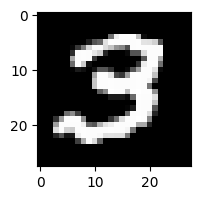

In [ ]:
plt.figure(figsize=(2,2))
plt.imshow(images[4].squeeze(), cmap="gray")
plt.show()

In [ ]:
labels[4]

tensor(3)

### Train a Fully Connected Neural Network (FCNN)

In [ ]:
from torch.autograd import forward_ad
from torch.nn.modules import linear
class DigitClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.network=nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)

    )
  def forward(self,x):
    return self.network(x)


In [ ]:
model=DigitClassifier()
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

In [ ]:
epochs=5

for epoch in range(epochs):
  running_loss=0.0
  for images,labels in train_loader:
    #1.Forward pass
    outputs=model(images)
    loss=criterion(outputs,labels)
    running_loss+=loss.item()
    #2.Backward pass
    optimizer.zero_grad()
    loss.backward()
    #3. Weights updated
    optimizer.step() #w_oold =W_new-n*d(loss)/dw

  print(f"[{epoch+1/epochs}], Loss: {running_loss/len(train_loader):.2f}")

[0.2], Loss: 0.39
[1.2], Loss: 0.18
[2.2], Loss: 0.14
[3.2], Loss: 0.11
[4.2], Loss: 0.10


In [ ]:
# Testing the model
model.eval()  # Switch to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 96.59%


In [ ]:
total,correct

(10000, 9659)

List item



In [ ]:
List item

In [ ]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Instantiate the model, define loss function and optimizer
model = DigitClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()          # Zero the gradients
        outputs = model(images)        # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                # Backpropagate
        optimizer.step()               # Update weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/5], Loss: 0.4104
Epoch [2/5], Loss: 0.1968
Epoch [3/5], Loss: 0.1436
Epoch [4/5], Loss: 0.1146
Epoch [5/5], Loss: 0.0976


In [ ]:
# Testing the model
model.eval()  # Switch to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 96.80%


### Classification Report & Confusion Matrix

*   List item
*   List item



In [ ]:
# Testing the model
model.eval()  # Switch to evaluation mode

all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        # Append labels and predictions to lists
        all_labels.extend(labels.numpy())
        all_predicted.extend(predicted.numpy())

In [ ]:
len(all_predicted)

10000

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_predicted)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.96      0.97      0.97      1032
           3       0.93      0.98      0.96      1010
           4       0.96      0.98      0.97       982
           5       0.98      0.95      0.97       892
           6       0.95      0.98      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.93      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_predicted)
cm

array([[ 956,    0,    6,    2,    0,    2,    9,    1,    2,    2],
       [   0, 1128,    1,    1,    0,    0,    3,    0,    2,    0],
       [   4,    3, 1001,    7,    4,    0,    1,   10,    2,    0],
       [   0,    1,    8,  989,    0,    3,    0,    7,    2,    0],
       [   0,    0,    3,    0,  962,    0,    8,    3,    2,    4],
       [   2,    2,    0,   27,    2,  848,    8,    0,    2,    1],
       [   2,    3,    2,    3,    3,    3,  942,    0,    0,    0],
       [   1,   14,   14,    1,    0,    0,    1,  984,    0,   13],
       [   1,    4,    5,   22,    4,    7,   14,    9,  905,    3],
       [   3,    5,    2,    9,   29,    1,    2,   13,    1,  944]])

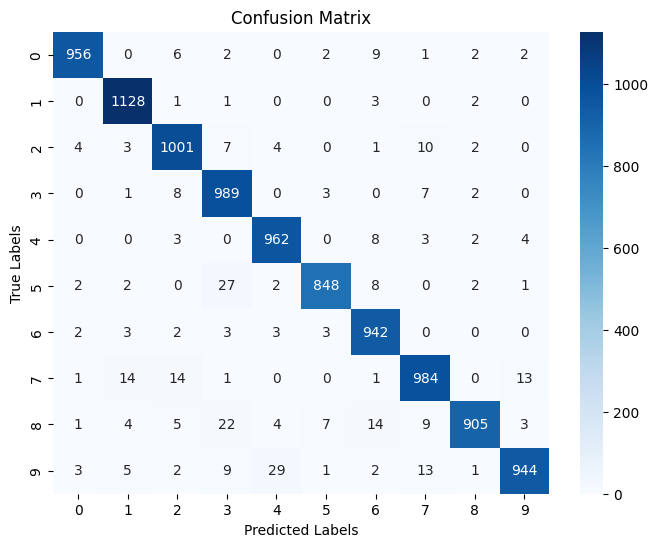

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(len(cm)), yticklabels=range(len(cm)))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()